# Detección de rostros con Haar

**Duración estimada:** 55 minutos

## Objetivo

En este cuaderno vas a usar una cascada de Haar sobre un retrato real para entender cómo trabaja un detector clásico entrenado.


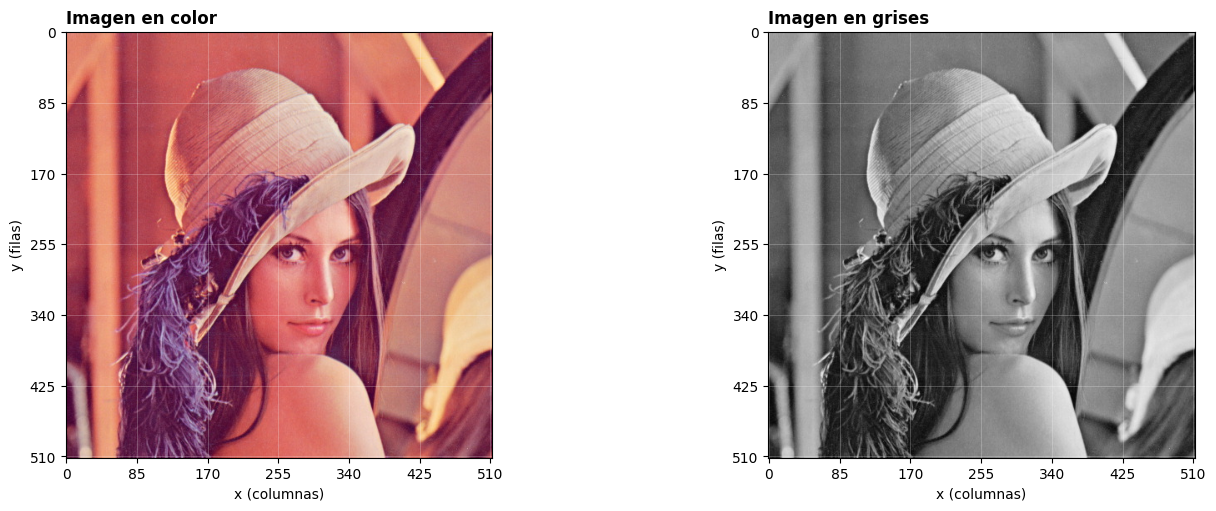

Archivo de cascada usado: D:\IFTS24-Cuadernos 2026\ifts24-lab-pdi-2026\.venv\Lib\site-packages\cv2\data\haarcascade_frontalface_default.xml


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()

imagen_bgr = abrir_imagen_bgr("valeria.png")
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
imagen_grises = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

ruta_cascada = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
detector_haar = cv2.CascadeClassifier(str(ruta_cascada))

mostrar_varias_imagenes(
    [imagen_rgb, imagen_grises],
    ["Imagen en color", "Imagen en grises"],
    [None, "gray"],
    tamano=(14, 5),
)

print("Archivo de cascada usado:", ruta_cascada)


## 1. Dos configuraciones para comparar

Vamos a probar dos configuraciones de `detectMultiScale()` para ver cómo cambian las detecciones. La idea no es memorizar números, sino entender que los parámetros forman parte del criterio de análisis.


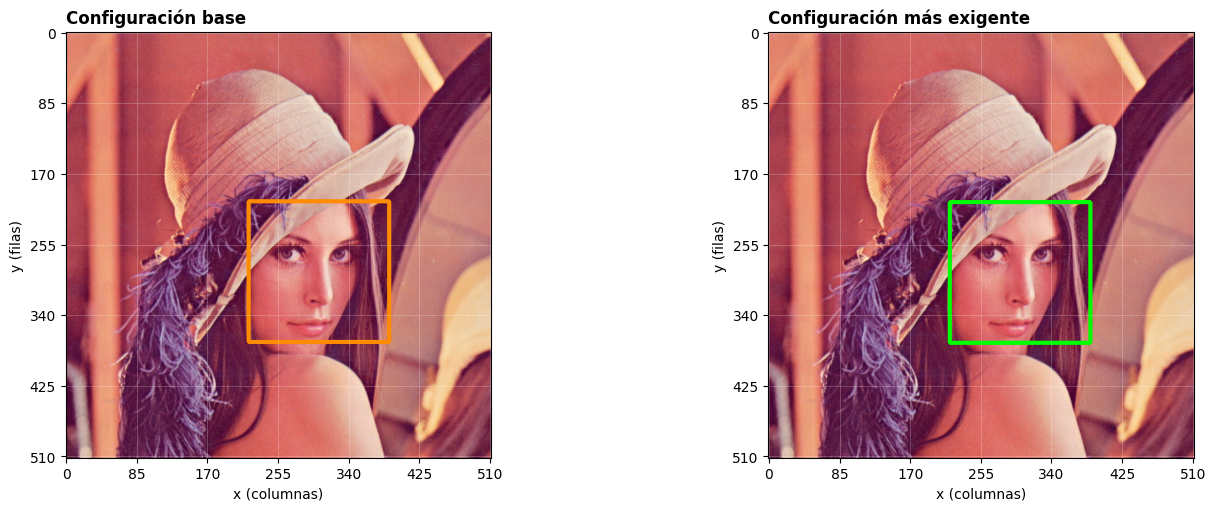

Detecciones con configuración base: 1
Detecciones con configuración más exigente: 1


In [2]:
rostros_base = detector_haar.detectMultiScale(
    imagen_grises,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40, 40),
)

rostros_exigentes = detector_haar.detectMultiScale(
    imagen_grises,
    scaleFactor=1.05,
    minNeighbors=7,
    minSize=(40, 40),
)

imagen_base = imagen_rgb.copy()
imagen_exigente = imagen_rgb.copy()

for x, y, ancho, alto in rostros_base:
    cv2.rectangle(imagen_base, (x, y), (x + ancho, y + alto), (255, 140, 0), 3)

for x, y, ancho, alto in rostros_exigentes:
    cv2.rectangle(imagen_exigente, (x, y), (x + ancho, y + alto), (0, 255, 0), 3)

mostrar_varias_imagenes(
    [imagen_base, imagen_exigente],
    ["Configuración base", "Configuración más exigente"],
    tamano=(14, 5),
)

print("Detecciones con configuración base:", len(rostros_base))
print("Detecciones con configuración más exigente:", len(rostros_exigentes))


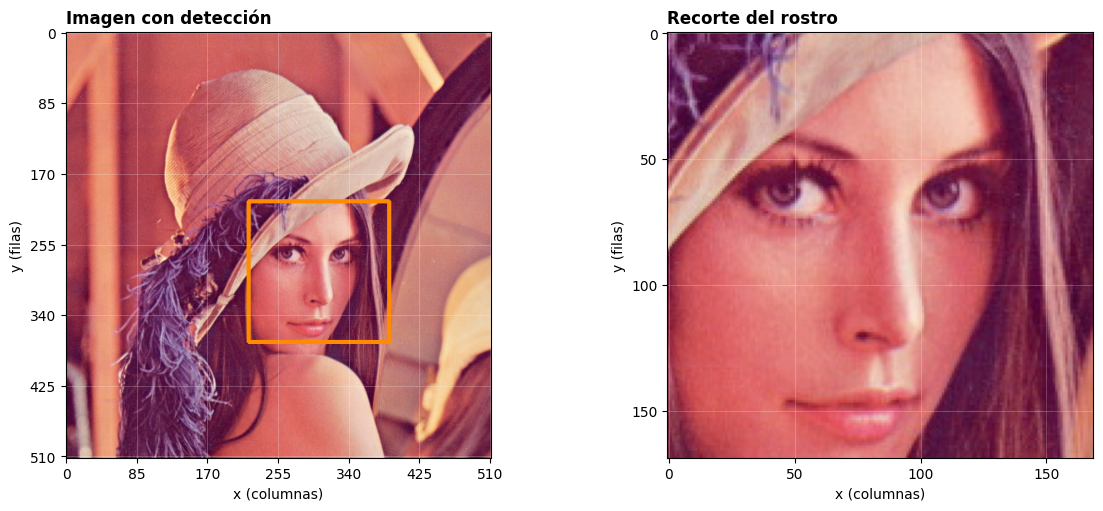

In [3]:
if len(rostros_base) > 0:
    x, y, ancho, alto = rostros_base[0]
    recorte_rostro = imagen_rgb[y:y + alto, x:x + ancho]

    mostrar_varias_imagenes(
        [imagen_base, recorte_rostro],
        ["Imagen con detección", "Recorte del rostro"],
        tamano=(12, 5),
    )
else:
    print("No hubo detecciones para recortar.")


## Cierre

Las cascadas de Haar siguen siendo muy útiles para aprender cómo un detector clásico pasa de una imagen a una región candidata. No son el último estado del arte, pero sí una muy buena puerta de entrada a la lógica de detección.
